# Artificial Intelligence
# 464
# Project #4

## Before You Begin...
00. We're using a Jupyter Notebook environment (tutorial available here: https://jupyter-notebook-beginner-guide.readthedocs.io/en/latest/what_is_jupyter.html),
01. Read the entire notebook before beginning your work, and
02.  Check the submission deadline on Gradescope.


## General Directions for this Assignment
00. Output format should be exactly as requested,
01. Functions should do only one thing,
02. Keep functions to 20 lines or less (empty lines are fine, there's leeway, but don't blatantly ignore this),
03. Add docstring to all functions,


## Before You Submit...
00. Re-read the general instructions provided above, and
01. Hit "Kernel"->"Restart & Run All". The first cell that is run should show [1], the second should show [2], and so on...
02. Submit your notebook (as .ipynb, not PDF) using Gradescope, and
03.  Do not submit any other files.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import networkx as nx
from copy import deepcopy
import networkx as nx


You might need to do a install to work with networkx

```
pip install networkx
```

## Map Coloring

It turns out that any division of a plane into contiguous regions can be colored such that no two adjacent regions are the same color by using only four colors (see [Four Color Theorem](http://en.wikipedia.org/wiki/Four_color_theorem), for more details) This **Constraint Satisfaction Problem** can be viewed as a constraint graph, where variables are nodes and no adjacent nodes can be of the same color.


Our first constraint graph is the dictionary `connecticut_graph` with three keys: 1) "nodes," which is a ordered list of strings that represent the nodes; 2) "edges," which indicates with tuples which nodes are adjacent; and 3) the "coordinates" key helps NetworkX make cartoons.

In [2]:
connecticut_graph = { "nodes": ["Fairfield", "Litchfield", "New Haven", "Hartford", "Middlesex", "Tolland", "New London", "Windham"],
                "edges": [(0,1), (0,2), (1,2), (1,3), (2,3), (2,4), (3,4), (3,5), (3,6), (4,6), (5,6), (5,7), (6,7)],
                "coordinates": [( 46, 52), ( 65,142), (104, 77), (123,142), (147, 85), (162,140), (197, 94), (217,146)]}
print(connecticut_graph)

{'nodes': ['Fairfield', 'Litchfield', 'New Haven', 'Hartford', 'Middlesex', 'Tolland', 'New London', 'Windham'], 'edges': [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (2, 4), (3, 4), (3, 5), (3, 6), (4, 6), (5, 6), (5, 7), (6, 7)], 'coordinates': [(46, 52), (65, 142), (104, 77), (123, 142), (147, 85), (162, 140), (197, 94), (217, 146)]}


In [3]:
def select_unassigned_variable(assignment, domains):
    """
    MRV (Minimum Remaining Values):
    Selects an unassigned variable (node) that has the smallest domain size.
    
    Parameters:
        assignment (dict): Mapping of already assigned variables.
        domains (dict): Mapping of variables to their list of possible colors.
        
    Returns:
        int: The index of the unassigned variable with the smallest domain.
    """
    unassigned = [v for v in domains if v not in assignment]
    return min(unassigned, key=lambda v: len(domains[v]))

In [4]:
def order_domain_values(var, domains, neighbors, assignment):
    """
    LCV (Least Constraining Value):
    Orders the domain values for a given variable such that the value that
    rules out the fewest choices for neighboring unassigned variables comes first.
    
    Parameters:
        var (int): The variable (node index) to order values for.
        domains (dict): Mapping of variables to their list of possible colors.
        neighbors (dict): Mapping of each variable to its neighbor indices.
        assignment (dict): Mapping of already assigned variables.
        
    Returns:
        list: A list of color values ordered by least constraining first.
    """
    counts = {}
    for value in domains[var]:
        count = 0
        for neigh in neighbors[var]:
            if neigh not in assignment and value in domains[neigh]:
                count += 1
        counts[value] = count
    return sorted(domains[var], key=lambda val: counts[val])

In [5]:
def forward_check(var, value, domains, neighbors, assignment):
    """
    Forward Checking:
    After assigning a value to a variable, this function removes that value
    from the domains of all unassigned neighboring variables.
    
    Parameters:
        var (int): The variable (node index) that has been assigned a value.
        value (str): The color assigned to the variable.
        domains (dict): Mapping of variables to their current list of possible colors.
        neighbors (dict): Mapping of each variable to its neighbor indices.
        assignment (dict): Mapping of already assigned variables.
        
    Returns:
        dict or None: A new copy of the domains with the value removed from neighbors.
                      If any neighbor's domain becomes empty, returns None.
    """
    new_domains = {v: list(domains[v]) for v in domains}
    for neigh in neighbors[var]:
        if neigh not in assignment and value in new_domains[neigh]:
            new_domains[neigh].remove(value)
            if not new_domains[neigh]:
                return None
    return new_domains

In [6]:
def backtrack(assignment, domains, n, nodes, neighbors, trace):
    """
    Recursive Backtracking Search:
    Attempts to assign colors to all nodes using backtracking combined with forward checking,
    MRV for variable selection, and LCV for ordering values.
    
    Parameters:
        assignment (dict): Current mapping of node indices to assigned colors.
        domains (dict): Current mapping of node indices to their possible colors.
        n (int): Total number of nodes.
        nodes (list): List of node names.
        neighbors (dict): Mapping of node indices to neighboring node indices.
        trace (bool): Flag to print trace information.
        
    Returns:
        dict or None: A complete assignment mapping if successful; otherwise, None.
    """
    if len(assignment) == n:
        return assignment
    
    var = select_unassigned_variable(assignment, domains)
    for value in order_domain_values(var, domains, neighbors, assignment):
        # Check consistency: assigned neighbors must not have the same color.
        if all(value != assignment.get(neigh) for neigh in neighbors[var] if neigh in assignment):
            if trace:
                print(f"Assign {nodes[var]} = {value}")
            assignment[var] = value
            new_domains = forward_check(var, value, domains, neighbors, assignment)
            if new_domains is not None:
                result = backtrack(assignment, new_domains, n, nodes, neighbors, trace)
                if result is not None:
                    return result
            if trace:
                print(f"Backtrack on {nodes[var]}")
            del assignment[var]
    return None


In [7]:
def color_map(constraint_graph, color_list, trace=False):
    """
    Colors a map given as a constraint graph using backtracking with
    forward checking, MRV for variable selection, and LCV for ordering values.
    
    Parameters:
        constraint_graph (dict): A dictionary with keys "nodes", "edges", and "coordinates".
                                 - "nodes": a list of node names.
                                 - "edges": a list of tuples (i, j) indicating adjacent nodes.
                                 - "coordinates": positions for drawing (used with networkx).
        color_list (list): A list of colors (strings) available for coloring.
        trace (bool): If True, prints trace statements showing assignment and backtracking steps.
        
    Returns:
        list or None: A list of (node, color) tuples in the same order as constraint_graph["nodes"]
                      if a solution is found; otherwise, returns None.
    """
    nodes = constraint_graph["nodes"]
    n = len(nodes)
    edges = constraint_graph["edges"]
    
    # Build neighbor lookup: each node index maps to a list of neighbor indices.
    neighbors = {i: [] for i in range(n)}
    for i, j in edges:
        neighbors[i].append(j)
        neighbors[j].append(i)
    
    # Initialize domains: every node can be any color initially.
    domains = {i: color_list[:] for i in range(n)}
    
    solution = backtrack({}, domains, n, nodes, neighbors, trace)
    if solution is None:
        return None
    # Return the solution as a list of (node, color) tuples matching the ordering in constraint_graph["nodes"].
    return [(nodes[i], solution[i]) for i in range(n)]


In [8]:
def test_coloring(constraint_graph, solution):
    """
    This function tests the solution resulting from `color_map`. 
    Adjacent nodes in the solution cannot be of the same color.
    constraint_graph is the dict with keys: nodes, edges, and coordinates.
    solution is a list of (node name, assigned color) tuples
    Returns a warning statement if there's a violation
    """
    nodes = constraint_graph[ "nodes"]
    edges = constraint_graph["edges"]
    for start, end in edges:
        try:
            assert solution[start][1] != solution[end][1]
        except AssertionError:
            print(f"{nodes[start]} and {nodes[end]} are adjacent but have the same color.")

In [9]:
def draw_map(title, constraint_graph, size, solution=None):
    """
    This function uses Networkx to draw the `constraint_graph` (dict keys: nodes, edges, and coordinate) 
    Nodes are colored using `solution`, a list of (node name, assigned color) tuples
    title is the title for the cartoon
    size is in inches wide x inches tall, so (8,10) results in 8"x10" rendering (depends on monitor)
    """
    
    def as_dictionary(a_list):
        dct = {}
        for i, e in enumerate(a_list):
            dct[i] = e
        return dct
    
    G = nx.Graph()
    
    labels = as_dictionary(constraint_graph["nodes"])
    pos = as_dictionary(constraint_graph["coordinates"])
    
    # create a List of Nodes as indices to match the "edges" entry.
    nodes = [n for n in range(0, len(constraint_graph["nodes"]))]

    if solution:
        colors = [c for n, c in solution]
    else:
        colors = ['red' for c in range(0,len(constraint_graph["nodes"]))]

    G.add_nodes_from(nodes)
    G.add_edges_from(constraint_graph["edges"])

    plt.figure(figsize=size, dpi=100)
    plt.title(title)
    nx.draw(G, node_color = colors, with_labels = True, labels = labels, pos = pos)
    
#    plt.savefig(name + ".png")

## Problem 1. Color Connecticut with Four Colors

In [10]:
connecticut_solution = color_map(connecticut_graph, ["red", "blue", "green", "yellow"], trace=True)

Assign Fairfield = red
Assign Litchfield = blue
Assign New Haven = green
Assign Hartford = red
Assign Middlesex = blue
Assign New London = green
Assign Tolland = blue
Assign Windham = red


## Test Connecticut Solution

In [11]:
if connecticut_solution:
    test_coloring(connecticut_graph, connecticut_solution)

## Draw Connecticut Cartoon

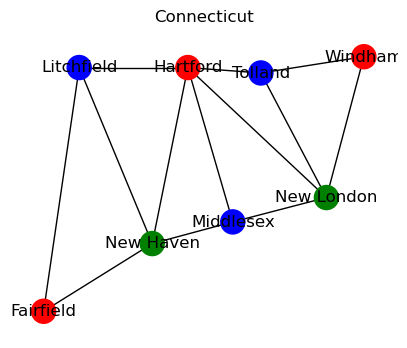

In [12]:
if connecticut_solution:
    draw_map("Connecticut", connecticut_graph, (5,4), connecticut_solution)

## Problem 2. Color Connecticut with Three Colors

In [13]:
connecticut_solution = color_map(connecticut_graph, ["red", "blue", "green"], trace=True)

Assign Fairfield = red
Assign Litchfield = blue
Assign New Haven = green
Assign Hartford = red
Assign Middlesex = blue
Assign New London = green
Assign Tolland = blue
Assign Windham = red


## Test Connecticut Solution

In [14]:
if connecticut_solution:
    test_coloring(connecticut_graph, connecticut_solution)

## Draw Connecticut Cartoon

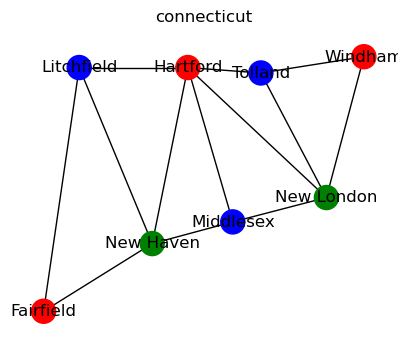

In [15]:
if connecticut_solution:
    draw_map("connecticut", connecticut_graph, (5,4), connecticut_solution)

## Problem 3. Color Europe with Four Colors

In [16]:
europe_graph = {
    "nodes":  ["Iceland", "Ireland", "United Kingdom", "Portugal", "Spain",
                 "France", "Belgium", "Netherlands", "Luxembourg", "Germany",
                 "Denmark", "Norway", "Sweden", "Finland", "Estonia",
                 "Latvia", "Lithuania", "Poland", "Czech Republic", "Austria",
                 "Liechtenstein", "Switzerland", "Italy", "Malta", "Greece",
                 "Albania", "Macedonia", "Kosovo", "Montenegro", "Bosnia Herzegovina",
                 "Serbia", "Croatia", "Slovenia", "Hungary", "Slovakia",
                 "Belarus", "Ukraine", "Moldova", "Romania", "Bulgaria",
                 "Cyprus", "Turkey", "Georgia", "Armenia", "Azerbaijan",
                 "Russia" ], 
    "edges": [(0,1), (0,2), (1,2), (2,5), (2,6), (2,7), (2,11), (3,4),
                 (4,5), (4,22), (5,6), (5,8), (5,9), (5,21), (5,22),(6,7),
                 (6,8), (6,9), (7,9), (8,9), (9,10), (9,12), (9,17), (9,18),
                 (9,19), (9,21), (10,11), (10,12), (10,17), (11,12), (11,13), (11,45), 
                 (12,13), (12,14), (12,15), (12,17), (13,14), (13,45), (14,15),
                 (14,45), (15,16), (15,35), (15,45), (16,17), (16,35), (17,18),
                 (17,34), (17,35), (17,36), (18,19), (18,34), (19,20), (19,21), 
                 (19,22), (19,32), (19,33), (19,34), (20,21), (21,22), (22,23),
                 (22,24), (22,25), (22,28), (22,29), (22,31), (22,32), (24,25),
                 (24,26), (24,39), (24,40), (24,41), (25,26), (25,27), (25,28),
                 (26,27), (26,30), (26,39), (27,28), (27,30), (28,29), (28,30),
                 (29,30), (29,31), (30,31), (30,33), (30,38), (30,39), (31,32),
                 (31,33), (32,33), (33,34), (33,36), (33,38), (34,36), (35,36),
                 (35,45), (36,37), (36,38), (36,45), (37,38), (38,39), (39,41),
                 (40,41), (41,42), (41,43), (41,44), (42,43), (42,44), (42,45),
                 (43,44), (44,45)],
    "coordinates": [( 18,147), ( 48, 83), ( 64, 90), ( 47, 28), ( 63, 34),
                   ( 78, 55), ( 82, 74), ( 84, 80), ( 82, 69), (100, 78),
                   ( 94, 97), (110,162), (116,144), (143,149), (140,111),
                   (137,102), (136, 95), (122, 78), (110, 67), (112, 60),
                   ( 98, 59), ( 93, 55), (102, 35), (108, 14), (130, 22),
                   (125, 32), (128, 37), (127, 40), (122, 42), (118, 47),
                   (127, 48), (116, 53), (111, 54), (122, 57), (124, 65),
                   (146, 87), (158, 65), (148, 57), (138, 54), (137, 41),
                   (160, 13), (168, 29), (189, 39), (194, 32), (202, 33),
                   (191,118)]}
print(europe_graph)

{'nodes': ['Iceland', 'Ireland', 'United Kingdom', 'Portugal', 'Spain', 'France', 'Belgium', 'Netherlands', 'Luxembourg', 'Germany', 'Denmark', 'Norway', 'Sweden', 'Finland', 'Estonia', 'Latvia', 'Lithuania', 'Poland', 'Czech Republic', 'Austria', 'Liechtenstein', 'Switzerland', 'Italy', 'Malta', 'Greece', 'Albania', 'Macedonia', 'Kosovo', 'Montenegro', 'Bosnia Herzegovina', 'Serbia', 'Croatia', 'Slovenia', 'Hungary', 'Slovakia', 'Belarus', 'Ukraine', 'Moldova', 'Romania', 'Bulgaria', 'Cyprus', 'Turkey', 'Georgia', 'Armenia', 'Azerbaijan', 'Russia'], 'edges': [(0, 1), (0, 2), (1, 2), (2, 5), (2, 6), (2, 7), (2, 11), (3, 4), (4, 5), (4, 22), (5, 6), (5, 8), (5, 9), (5, 21), (5, 22), (6, 7), (6, 8), (6, 9), (7, 9), (8, 9), (9, 10), (9, 12), (9, 17), (9, 18), (9, 19), (9, 21), (10, 11), (10, 12), (10, 17), (11, 12), (11, 13), (11, 45), (12, 13), (12, 14), (12, 15), (12, 17), (13, 14), (13, 45), (14, 15), (14, 45), (15, 16), (15, 35), (15, 45), (16, 17), (16, 35), (17, 18), (17, 34), (17, 

In [17]:
europe_solution = color_map(europe_graph, ["red", "blue", "green", "yellow"], trace=False)

## Test Europe Solution

In [18]:
if europe_solution:
    test_coloring(europe_graph, europe_solution)

## Draw Europe Cartoon

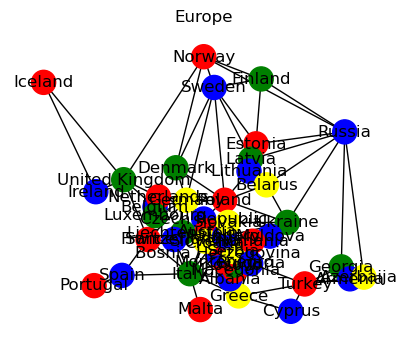

In [19]:
if europe_solution:
    draw_map("Europe", europe_graph, (5,4), europe_solution)

## Problem 4. Color Europe with Three Colors

In [20]:
europe_solution = color_map(europe_graph, ["red", "blue", "green"], trace=False)

## Test Europe Solution

In [21]:
if europe_solution:
    test_coloring(europe_graph, europe_solution)

## Draw Europe Cartoon

In [22]:
if europe_solution:
    draw_map("Europe", europe_graph, (5,4), europe_solution)

## Before You Submit...

00. Re-read the general instructions provided above, and
01. Hit "Kernel"->"Restart & Run All". The first cell that is run should show [1], the second should show [2], and so on...
02. Submit your notebook (as .ipynb, not PDF) using Gradescope, and
03.  Do not submit any other files.